In [90]:
import pandas as pd

In [91]:
df=pd.read_csv('../data/german_credit_data.csv')
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


In [92]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [94]:
df.shape

(1000, 11)

In [95]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [96]:
df.head(20)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,35,male,3,rent,little,moderate,6948,36,car,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad


In [97]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [98]:
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

In [99]:
df['Saving accounts'] = df['Saving accounts'].fillna('No account')

In [100]:
df['Checking account'] = df['Checking account'].fillna('No account')

In [101]:
df.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [102]:
df.head(20)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,No account,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,No account,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1
5,35,male,1,free,No account,No account,9055,36,education,0
6,53,male,2,own,quite rich,No account,2835,24,furniture/equipment,0
7,35,male,3,rent,little,moderate,6948,36,car,0
8,61,male,1,own,rich,No account,3059,12,radio/TV,0
9,28,male,3,own,little,moderate,5234,30,car,1


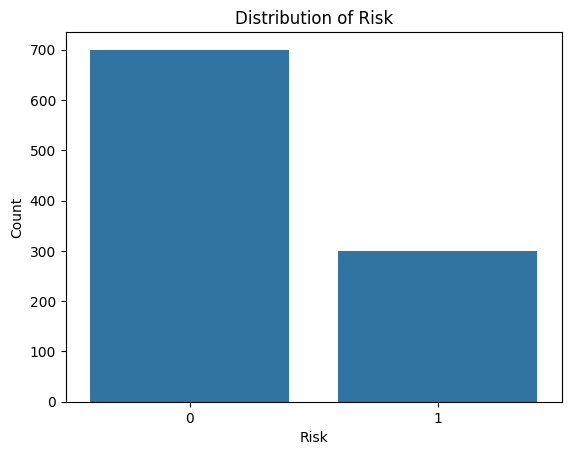

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Risk',data=df)
plt.title('Distribution of Risk')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Risk', ylabel='Credit amount'>

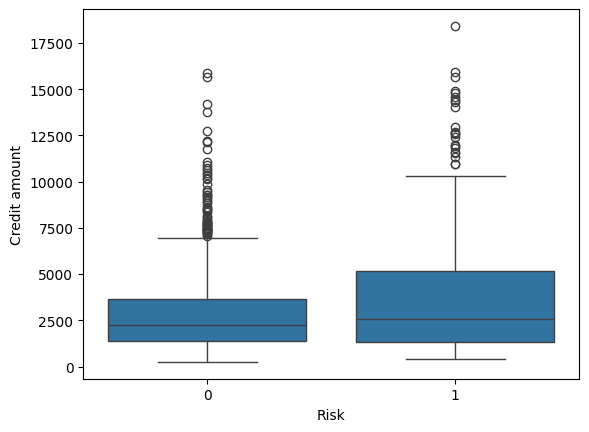

In [104]:
#lets check the relation of risk with credit amount
sns.boxplot(x='Risk',y='Credit amount',data=df)


<Axes: xlabel='Risk', ylabel='Duration'>

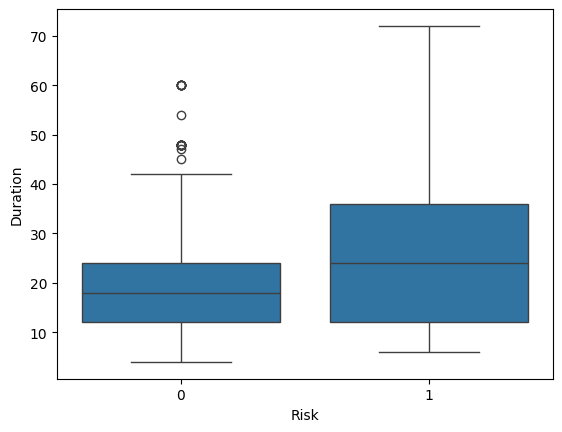

In [105]:
sns.boxplot(x='Risk',y='Duration',data=df)

<Axes: xlabel='Risk', ylabel='Age'>

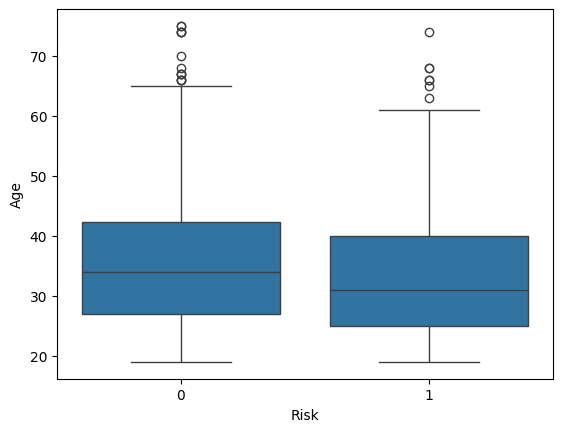

In [106]:
sns.boxplot(x='Risk',y='Age',data=df)

In [107]:
#splitting the data into features and target variable
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Risk'])
y=df['Risk']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [108]:
df['Risk'].dtype

dtype('int64')

In [109]:
#preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [110]:
nums_cols=['Age','Duration','Credit amount']
ord_cols=['Saving accounts','Checking account','Job']
nomi_cols=['Sex','Housing','Purpose']

In [111]:
saving_order = ["No account", "little", "moderate", "quite rich", "rich"]
checking_order = ["No account", "little", "moderate", "rich"]

ordinal_encoder = OrdinalEncoder(
    categories=[saving_order, checking_order, [0,1,2,3]]
)

In [112]:
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ord_cols),
        ("nom", onehot_encoder, nomi_cols),
        ("num", "passthrough", nums_cols)
    ]
)

In [114]:
#transform the training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
#transform the testing data
X_test_preprocessed = preprocessor.transform(X_test)

In [115]:
#important part- Training the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_preprocessed,y_train)


d:\Credit Risk Assessment\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [116]:
y_pred = model.predict(X_test_preprocessed)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0])

In [117]:
y_prob = model.predict_proba(X_test_preprocessed)[:,1]
y_prob

array([0.29288296, 0.25428978, 0.15153792, 0.23765607, 0.35152044,
       0.23864359, 0.40680997, 0.44628747, 0.52185891, 0.30930765,
       0.15712592, 0.26942394, 0.06877169, 0.4580694 , 0.49790115,
       0.06114285, 0.38059322, 0.08973149, 0.13935857, 0.15372389,
       0.14182159, 0.19484459, 0.10169297, 0.58708783, 0.40687136,
       0.29786793, 0.08632075, 0.33591759, 0.17751547, 0.1725926 ,
       0.06558675, 0.18377764, 0.29101668, 0.59796979, 0.25622713,
       0.21347687, 0.30259742, 0.71404093, 0.14896571, 0.27935191,
       0.30001669, 0.47887213, 0.44775603, 0.4248377 , 0.44708908,
       0.07333548, 0.49026778, 0.70024347, 0.19092128, 0.23077801,
       0.13920097, 0.16526651, 0.2186494 , 0.59301191, 0.32012853,
       0.29845669, 0.13447052, 0.21472861, 0.27999941, 0.38838637,
       0.39720043, 0.41254214, 0.4822304 , 0.35353989, 0.19723751,
       0.4219367 , 0.08980528, 0.19755851, 0.61701815, 0.42131128,
       0.3384315 , 0.37259699, 0.21455716, 0.34908085, 0.28549

In [118]:
#evaluation
from sklearn.metrics import roc_auc_score,classification_report,confusion_matrix,accuracy_score
print(f"Report: {classification_report(y_test,y_pred)}")
print(f"Confusion Matrix: {confusion_matrix(y_test,y_pred)}")
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(f"Roc auc score: {roc_auc_score(y_test, y_prob)}")

Report:               precision    recall  f1-score   support

           0       0.74      0.94      0.83       140
           1       0.62      0.25      0.36        60

    accuracy                           0.73       200
   macro avg       0.68      0.59      0.59       200
weighted avg       0.71      0.73      0.69       200

Confusion Matrix: [[131   9]
 [ 45  15]]
Accuracy Score: 0.73
Roc auc score: 0.6992857142857142


#as recall for the minorty class(bad risk) is more important than overall accuracy, we can use class_weight='balanced' to give more weight to the minority class


In [119]:
model2=LogisticRegression(class_weight='balanced')
model2.fit(X_train_preprocessed,y_train)
y_pred2 = model2.predict(X_test_preprocessed)
y_pred2

d:\Credit Risk Assessment\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0])

In [120]:
#metrics for model2
print(f"Report: {classification_report(y_test,y_pred2)}")
print(f"Confusion Matrix: {confusion_matrix(y_test,y_pred2)}")
print(f"Accuracy Score: {accuracy_score(y_test,y_pred2)}")
y_prob2 = model2.predict_proba(X_test_preprocessed)[:,1]
print(f"Roc auc score: {roc_auc_score(y_test, y_prob2)}")


Report:               precision    recall  f1-score   support

           0       0.80      0.66      0.72       140
           1       0.44      0.62      0.51        60

    accuracy                           0.65       200
   macro avg       0.62      0.64      0.62       200
weighted avg       0.69      0.65      0.66       200

Confusion Matrix: [[92 48]
 [23 37]]
Accuracy Score: 0.645
Roc auc score: 0.6860714285714286


In [121]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
model3.fit(X_train_preprocessed,y_train)
y_pred3 = model3.predict(X_test_preprocessed)
y_prob3 = model3.predict_proba(X_test_preprocessed)[:,1]


In [122]:
from sklearn.metrics import roc_auc_score,classification_report,confusion_matrix,accuracy_score
print(f"Report: {classification_report(y_test,y_pred3)}")
print(f"Confusion Matrix: {confusion_matrix(y_test,y_pred3)}")
print(f"Accuracy Score: {accuracy_score(y_test,y_pred3)}")
print(f"Roc auc score: {roc_auc_score(y_test, y_prob3)}")

Report:               precision    recall  f1-score   support

           0       0.78      0.93      0.85       140
           1       0.70      0.38      0.49        60

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.67       200
weighted avg       0.75      0.77      0.74       200

Confusion Matrix: [[130  10]
 [ 37  23]]
Accuracy Score: 0.765
Roc auc score: 0.7545833333333333


In [123]:
#threshold tuning
import numpy as np
threshold = 0.4
y_pred3_threshold = (y_prob3 >= threshold).astype(int)


In [124]:
from sklearn.metrics import roc_auc_score,classification_report,confusion_matrix,accuracy_score
print(f"Report: {classification_report(y_test,y_pred3_threshold)}")
print(f"Confusion Matrix: {confusion_matrix(y_test,y_pred3_threshold)}")
print(f"Accuracy Score: {accuracy_score(y_test,y_pred3_threshold)}")
print(f"Roc auc score: {roc_auc_score(y_test, y_prob3)}")

Report:               precision    recall  f1-score   support

           0       0.79      0.78      0.78       140
           1       0.50      0.52      0.51        60

    accuracy                           0.70       200
   macro avg       0.64      0.65      0.65       200
weighted avg       0.70      0.70      0.70       200

Confusion Matrix: [[109  31]
 [ 29  31]]
Accuracy Score: 0.7
Roc auc score: 0.7545833333333333


roc is threshold independent so it did not change with threshold tuning


In [125]:
#feature importance
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['ord__Saving accounts' 'ord__Checking account' 'ord__Job'
 'nom__Sex_female' 'nom__Sex_male' 'nom__Housing_free' 'nom__Housing_own'
 'nom__Housing_rent' 'nom__Purpose_business' 'nom__Purpose_car'
 'nom__Purpose_domestic appliances' 'nom__Purpose_education'
 'nom__Purpose_furniture/equipment' 'nom__Purpose_radio/TV'
 'nom__Purpose_repairs' 'nom__Purpose_vacation/others' 'num__Age'
 'num__Duration' 'num__Credit amount']


In [126]:
importances = model3.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                             Feature  Importance
18                num__Credit amount    0.214473
16                          num__Age    0.165512
17                     num__Duration    0.150385
1              ord__Checking account    0.143185
0               ord__Saving accounts    0.081764
2                           ord__Job    0.052010
9                   nom__Purpose_car    0.023002
13             nom__Purpose_radio/TV    0.022536
6                   nom__Housing_own    0.020351
12  nom__Purpose_furniture/equipment    0.019536
3                    nom__Sex_female    0.018957
4                      nom__Sex_male    0.018337
8              nom__Purpose_business    0.016580
11            nom__Purpose_education    0.015542
7                  nom__Housing_rent    0.014208
5                  nom__Housing_free    0.012598
14              nom__Purpose_repairs    0.006542
10  nom__Purpose_domestic appliances    0.002419
15      nom__Purpose_vacation/others    0.002063


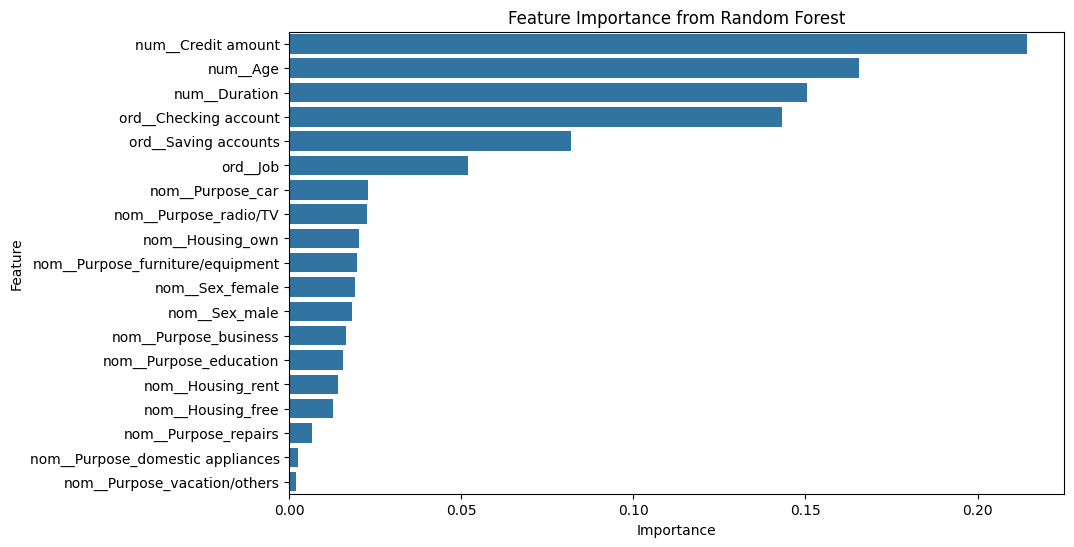

In [127]:
#lets plot the feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=feature_importance_df)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [128]:
#saving the model and preprocessor
from sklearn.pipeline import Pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42))
])

In [129]:
final_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [130]:
#create sample new data for prediction (using a few test samples)
new_data = X_test.iloc[:5].copy()
print("Sample new data:")
print(new_data)

Sample new data:
     Age   Sex  Job Housing Saving accounts Checking account  Credit amount  \
30    36  male    2     own            rich         moderate           1913   
128   34  male    3     own          little         moderate           1860   
289   48  male    2     own          little           little           1024   
216   31  male    2     own          little           little           3104   
966   23  male    1     own      quite rich         moderate           2520   

     Duration   Purpose  
30         18  business  
128        12       car  
289        24  radio/TV  
216        18  business  
966        27  radio/TV  


In [131]:
probs=final_pipeline.predict_proba(new_data)[:,1]
prediction=(probs >= 0.4).astype(int)

In [132]:
import joblib
joblib.dump(final_pipeline,'credit_risk_model.pkl')


['credit_risk_model.pkl']